In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# ---------- 1. LOAD FILES ----------
ho_file = "data/LTE Cell Relations KE.csv"
kpi_file = "data/2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

# ---------- 4. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
cells_kpi = set(node_list)
print("Number of KPI cells:", len(node_list))

# ---------- 5. CLEAN HO TABLE & EDGE LIST ----------
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Удаляем self-loops
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Фильтр по технологии, если есть RatBandShort
if "RatBandShort.1" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["RatBandShort.1"] == "L08"]
before = len(df_ho_clean)

# REMOVE INTRA-SITE RELATIONS
if "SITE_ID1" in df_ho_clean.columns and "SITE_ID2" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["SITE_ID1"] != df_ho_clean["SITE_ID2"]]
after = len(df_ho_clean)

print("Edges before removing intra-site:", before)
print("Edges after removing intra-site :", after)
print("Removed:", before - after)


Number of KPI cells: 197
Edges before removing intra-site: 3764
Edges after removing intra-site : 3384
Removed: 380


In [2]:
# ---------- 6. BUILD CELL NEIGHBOR TABLE ----------

# Функция извлечения BS
def extract_bs(cell_name):
    return cell_name[1:6]  # TK1ALP1 -> K1ALP (под твой формат)

# Добавляем BS
df_ho_clean["bs"] = df_ho_clean["source"].apply(extract_bs)

# Группируем по клетке
neighbor_table = (
    df_ho_clean
    .groupby("source")["target"]
    .agg(list)
    .reset_index()
)

# Добавляем BS
neighbor_table["bs"] = neighbor_table["source"].apply(extract_bs)

# Убираем дубликаты соседей (на всякий)
neighbor_table["target"] = neighbor_table["target"].apply(lambda x: list(set(x)))

# Количество соседей
neighbor_table["neighbor_count"] = neighbor_table["target"].apply(len)

# Переименование колонок
neighbor_table = neighbor_table.rename(columns={
    "source": "cell",
    "target": "neighbors"
})

# Сортировка (по желанию)
neighbor_table = neighbor_table.sort_values(by="neighbor_count", ascending=False)

# ---------- 7. SAVE ----------
neighbor_table.to_csv("cell_neighbor_table.csv", index=False)

# NEIGHBOR MEAN CORRELATION ANALYSIS:
Source Load ("4g_usage_%_lte_800") → Mean Neighbor Quality

### Hypoteza: Ak je bunka silne zaťažená (4g_usage_%_lte_800), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of 4g_usage_%_lte_800 on mean neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Source Load → Mean Neighbor Quality
4g_usage_%_lte_800 → mean cqi_tr1_4g_lte_800:
  Pearson r = -0.0502, p-value = 0.4893
4g_usage_%_lte_800 → mean cqi_tr2_4g_lte_800:
  Pearson r = 0.0113, p-value = 0.8765
4g_usage_%_lte_800 → mean mimo_rank_dl_4g_lte_800:
  Pearson r = -0.0680, p-value = 0.3488


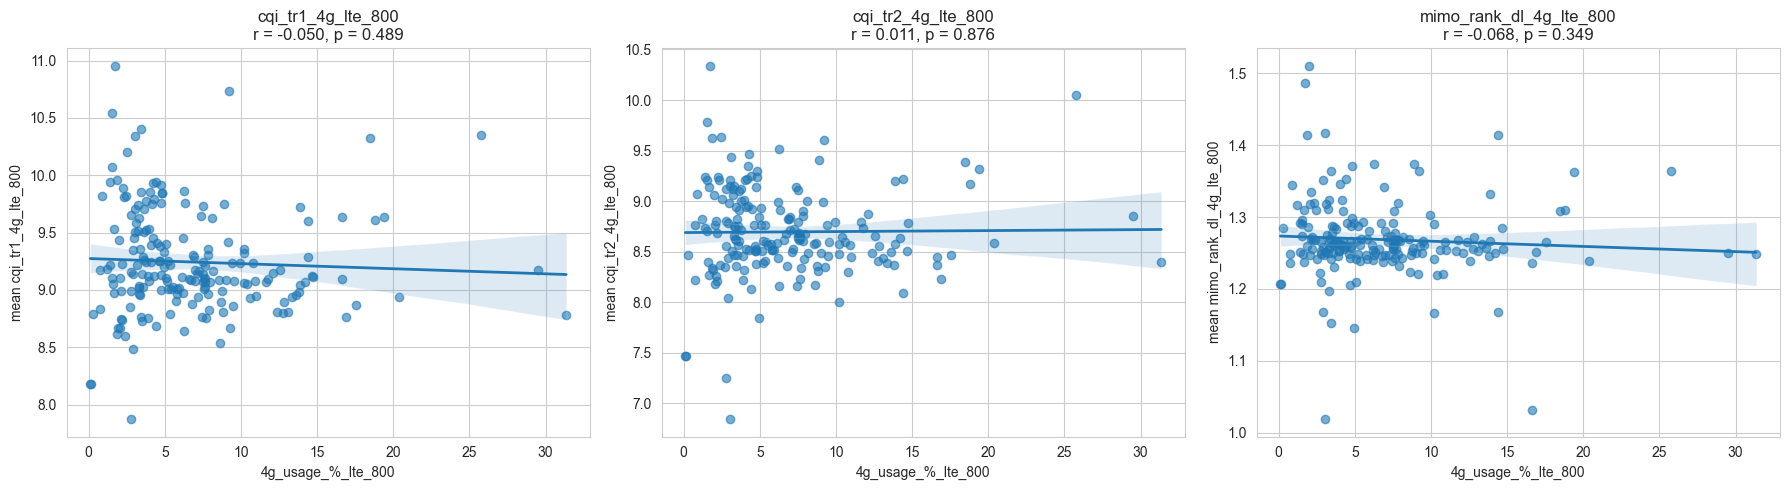

In [37]:
# DEFINITIONS
SOURCE_METRIC = "4g_usage_%_lte_800"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on mean neighbor quality:", TARGET_METRICS)

# 1. KPI MEDIANS PER CELL - для каждой клетки: берёт ВСЕ её значения по времени и считает среднее
kpi_mean = df_kpi.groupby("cell")[ [SOURCE_METRIC] + TARGET_METRICS ].mean()

# 2. BUILD CELL-LEVEL DATASET
records = []
for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    # Проверка наличия KPI у source
    if cell not in kpi_mean.index:
        continue
    source_value = kpi_mean.loc[cell, SOURCE_METRIC]
    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: source_value,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].mean()

    records.append(record)

neighbor_analysis = pd.DataFrame(records)
print("Valid cells for analysis:", len(neighbor_analysis))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Source Load → Mean Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis["source_" + SOURCE_METRIC]
    y = neighbor_analysis["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → mean {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("mean " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Nezistila sa žiadna významná korelácia medzi zaťažením bunky (4g_usage_%_lte_800) a kvalitou jej susedných buniek (CQI ani MIMO rank).

Hodnoty Pearsonovho koeficientu sú veľmi blízke nule a p-value je vysoké, čo znamená, že vzťah nie je štatisticky významný.

To naznačuje, že zaťaženie jednej bunky pravdepodobne nemá priamy vplyv na kvalitu jej susedov v tejto sieti.

# Vizualizacia -- Usage

BOXPLOT: Usage % → Mean Neighbor Quality


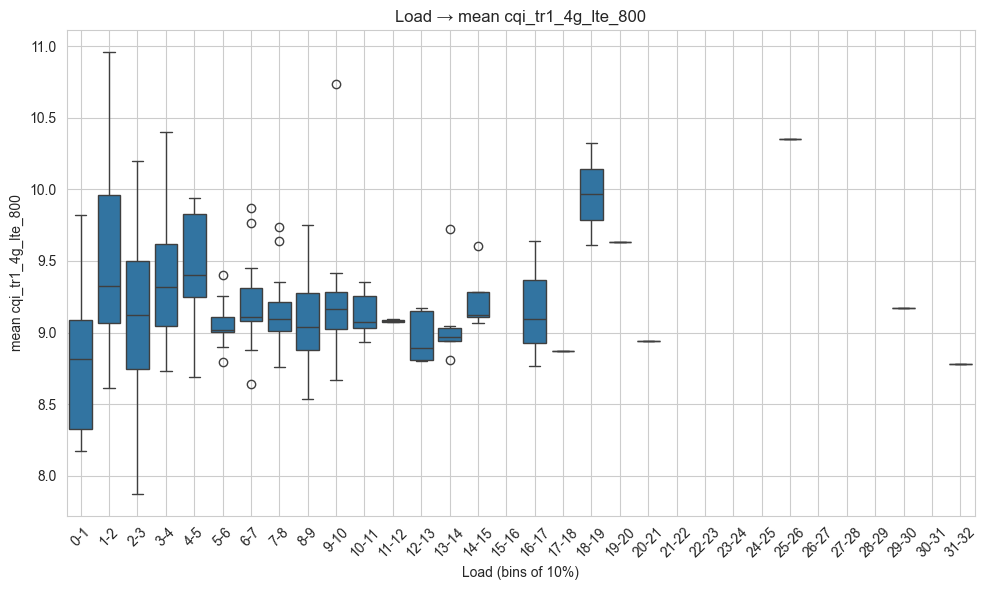

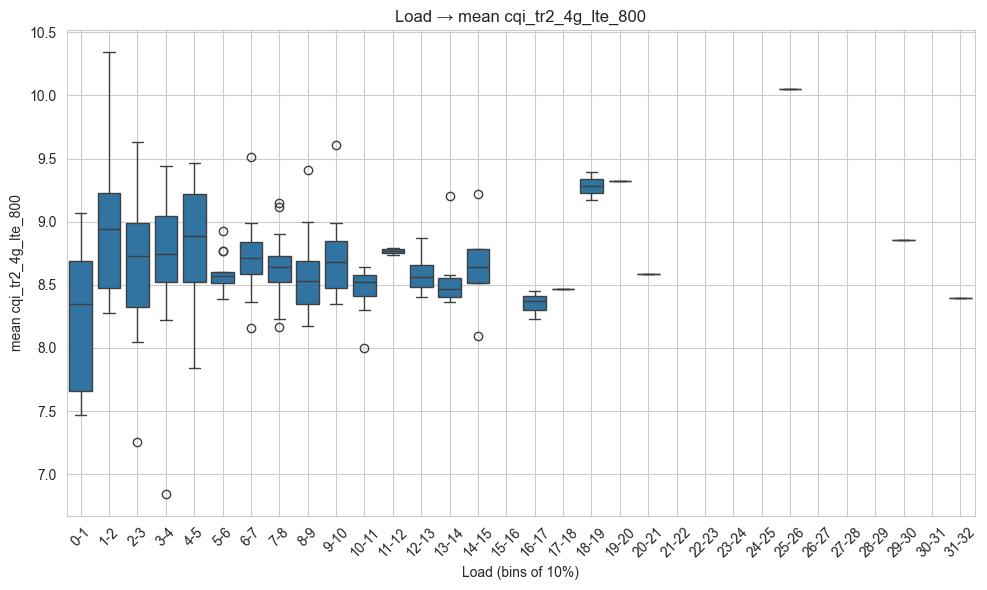

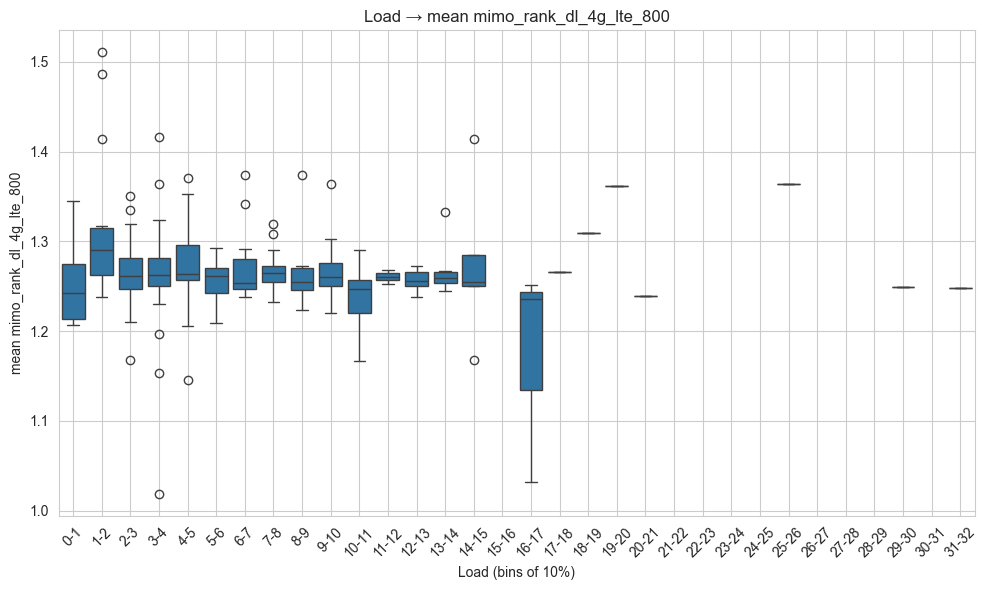

In [42]:
# BOXPLOT WITH FIXED BINS (LOAD-BASED)
print("BOXPLOT: Usage % → Mean Neighbor Quality")

# Ограничение по X (нагрузка в %)
max_load = 32
df_plot = neighbor_analysis[
    neighbor_analysis["source_4g_usage_%_lte_800"] <= max_load
].copy()

# создаём бины (например шаг = 10%)
bin_size = 1
bins = np.arange(0, max_load + bin_size, bin_size)

# labels вида "0-10", "10-20", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

df_plot["load_bin"] = pd.cut(
    df_plot["source_4g_usage_%_lte_800"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="load_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("Load (bins of 10%)")
    plt.ylabel("mean " + metric)
    plt.title(f"Load → mean {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # TODO popis LOad (bins)

Z grafov nevidno jasný trend, že by vyššia záťaž bunky viedla k horšej kvalite jej susedov.
Hodnoty CQI a MIMO sa medzi jednotlivými skupinami záťaže výrazne nemenia a majú podobný rozptyl.

# NEIGHBOR STRUCTURE CORRELATION ANALYSIS:
Neighbor Count → Mean Neighbor Quality

### Hypotéza: Ak má bunka veľa susedov (neighbor_count), potom priemerná kvalita jej susedných buniek (CQI, MIMO rank) je nižšia.

Analyzing impact of neighbor_count on mean neighbor quality: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid cells for analysis: 192

CORRELATION: Neighbor Count → Mean Neighbor Quality
neighbor_count → mean cqi_tr1_4g_lte_800:
  Pearson r = -0.3356, p-value = 0.0000
neighbor_count → mean cqi_tr2_4g_lte_800:
  Pearson r = -0.2058, p-value = 0.0042
neighbor_count → mean mimo_rank_dl_4g_lte_800:
  Pearson r = -0.2072, p-value = 0.0039


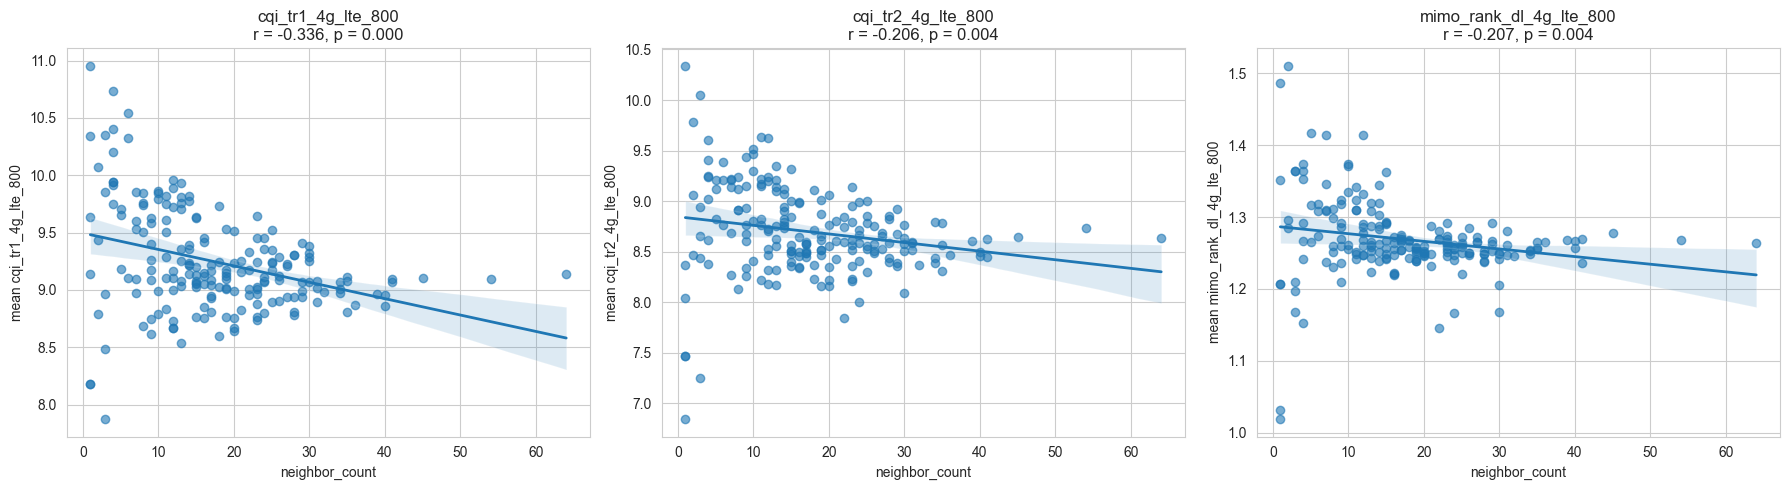

In [33]:
# DEFINITIONS
SOURCE_METRIC = "neighbor_count"

TARGET_METRICS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

print("Analyzing impact of", SOURCE_METRIC, "on mean neighbor quality:", TARGET_METRICS)


# 1. KPI MEAN PER CELL
kpi_mean = df_kpi.groupby("cell")[TARGET_METRICS].mean()


# 2. BUILD CELL-LEVEL DATASET
records = []

for _, row in neighbor_table.iterrows():
    cell = row["cell"]
    neighbors = row["neighbors"]
    neighbor_count = row["neighbor_count"]

    # KPI соседей
    neighbor_kpis = []
    for n in neighbors:
        if n in kpi_mean.index:
            neighbor_kpis.append(kpi_mean.loc[n, TARGET_METRICS])

    # если нет валидных соседей — пропускаем
    if len(neighbor_kpis) == 0:
        continue

    neighbor_df = pd.DataFrame(neighbor_kpis)

    record = {
        "cell": cell,
        "source_" + SOURCE_METRIC: neighbor_count,
        "neighbor_count": len(neighbor_kpis)
    }

    # среднее качество соседей
    for metric in TARGET_METRICS:
        record["neighbor_mean_" + metric] = neighbor_df[metric].mean()

    records.append(record)

neighbor_analysis = pd.DataFrame(records)

print("Valid cells for analysis:", len(neighbor_analysis))


# 3. CORRELATION + PLOTS
print("\n" + "="*60)
print("CORRELATION: Neighbor Count → Mean Neighbor Quality")
print("="*60)

# создаём 1 строку, 3 графика
fig, axes = plt.subplots(1, len(TARGET_METRICS), figsize=(18, 5))

for i, metric in enumerate(TARGET_METRICS):
    x = neighbor_analysis["source_" + SOURCE_METRIC]
    y = neighbor_analysis["neighbor_mean_" + metric]

    corr_val, p_val = pearsonr(x, y)
    print(f"{SOURCE_METRIC} → mean {metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.4f}")

    # PLOT
    sns.regplot(
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"linewidth": 2}
    )
    axes[i].set_xlabel(SOURCE_METRIC)
    axes[i].set_ylabel("mean " + metric)
    axes[i].set_title(
        f"{metric}\n"
        f"r = {corr_val:.3f}, p = {p_val:.3f}"
    )
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Existuje štatisticky významná negatívna korelácia medzi počtom susedov bunky a kvalitou jej susedných buniek (CQI aj MIMO rank).
To znamená, že bunky s väčším počtom susedov majú tendenciu mať horšiu priemernú kvalitu v okolí.
Výsledok naznačuje, že vyššia hustota susedov môže viesť k väčšiemu rušeniu (interference) v sieti.

# VISUALIZATION -- Neighbor Count

In [45]:
print(neighbor_analysis.columns)

Index(['cell', 'source_4g_usage_%_lte_800', 'neighbor_count',
       'neighbor_mean_cqi_tr1_4g_lte_800', 'neighbor_mean_cqi_tr2_4g_lte_800',
       'neighbor_mean_mimo_rank_dl_4g_lte_800'],
      dtype='object')


BOXPLOT: Neighbor Count → Mean Neighbor Quality


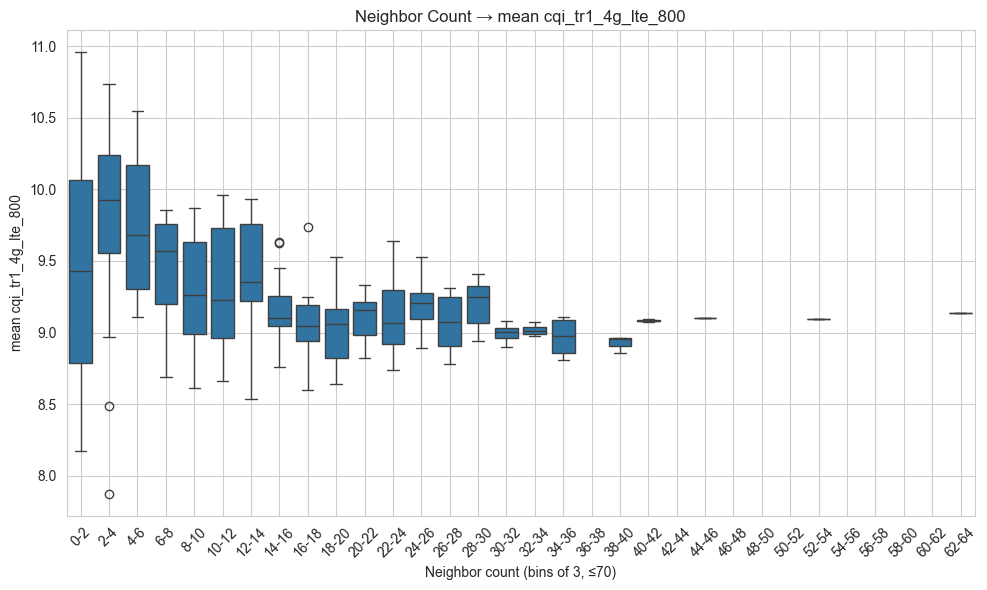

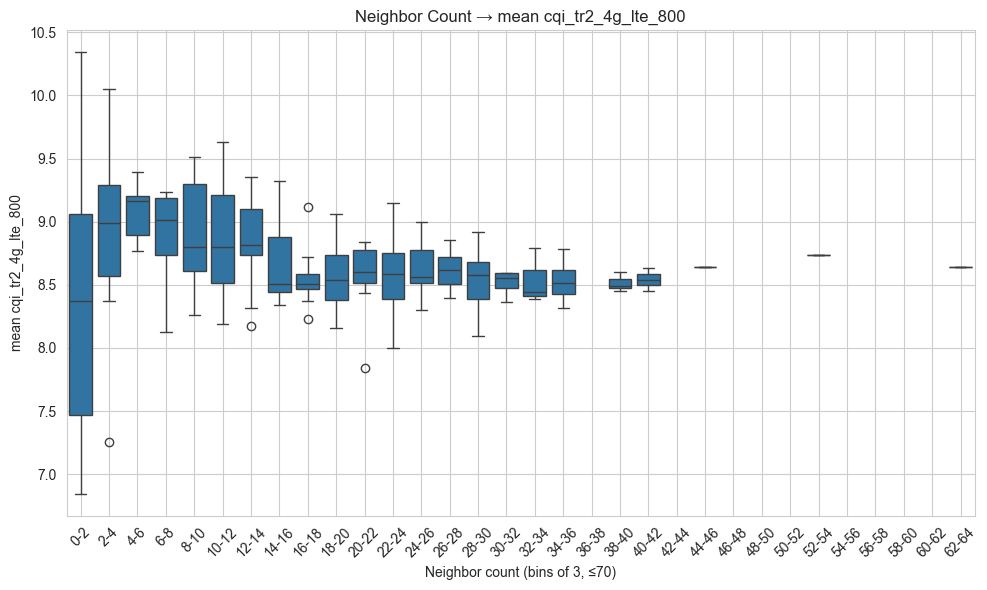

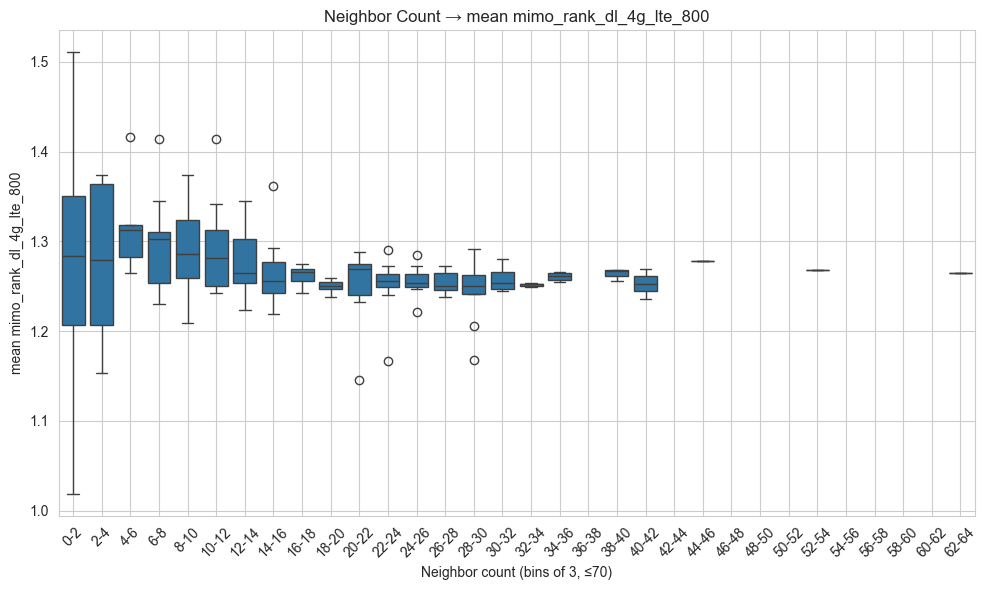

In [49]:
# BOXPLOT WITH FIXED BINS
print("BOXPLOT: Neighbor Count → Mean Neighbor Quality")

# Ограничение по X
max_neighbors = 64

df_plot = neighbor_analysis[
    neighbor_analysis["neighbor_count"] <= max_neighbors
].copy()

# создаём бины (шаг = 3)
bin_size = 2
bins = np.arange(0, max_neighbors + bin_size, bin_size)

# labels вида "0-3", "3-6", ...
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# используем именно neighbor_count
df_plot["neighbor_bin"] = pd.cut(
    df_plot["neighbor_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# PLOTS
for metric in TARGET_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_plot,
        x="neighbor_bin",
        y="neighbor_mean_" + metric
    )
    plt.xlabel("Neighbor count (bins of 3, ≤70)")
    plt.ylabel("mean " + metric)
    plt.title(f"Neighbor Count → mean {metric}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # TODO popisat noramrlne vysvetlenia ku grafam

Z grafov je vidieť mierny pokles kvality (CQI aj MIMO) so zvyšujúcim sa počtom susedov bunky.
To naznačuje, že bunky s veľkým počtom susedov môžu trpieť vyšším rušením (interference).

# RANDOM FOREST -- Predict Neighbor Quality

In [56]:
# ============================================================
# RANDOM FOREST: Predict Neighbor Quality
# Inputs:
#   1) usage%
#   2) usage% + neighbor_count
# Outputs:
#   mean CQI TR1, TR2, MIMO
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# TARGETS
TARGET_METRICS = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# FEATURES
FEATURE_1 = ["source_4g_usage_%_lte_800"]
FEATURE_2 = ["source_4g_usage_%_lte_800", "neighbor_count"]

# DATASET
df_model = neighbor_analysis.copy()
df_model = df_model.dropna() # Удаляем пропуски

print("Dataset size (number of cells):", len(df_model))


# ============================================================
# FUNCTION TO TRAIN & EVALUATE
# ============================================================

def train_and_evaluate(features, name):

    print(f"MODEL: {name}")
    X = df_model[features]
    y = df_model[TARGET_METRICS]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # evaluation per target
    for i, metric in enumerate(TARGET_METRICS):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

        print(f"{metric}:")
        print(f"  R2  = {r2:.4f}")
        print(f"  MAE = {mae:.4f}")
    return model


# RUN MODELS
model_usage_only = train_and_evaluate(FEATURE_1, "Usage only")
model_usage_neighbors = train_and_evaluate(FEATURE_2, "Usage + Neighbor Count")

Dataset size (number of cells): 192
MODEL: Usage only
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.0687
  MAE = 0.3205
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = -0.0124
  MAE = 0.2636
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.2727
  MAE = 0.0312
MODEL: Usage + Neighbor Count
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.3839
  MAE = 0.2694
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = 0.2107
  MAE = 0.2246
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.0847
  MAE = 0.0259


Model iba s usage% má veľmi slabý výkon a prakticky nedokáže dobre predpovedať kvalitu susedov (nízke alebo záporné R²).
Po pridaní počtu susedov sa model výrazne zlepšuje, najmä pre CQI metriky, čo znamená, že topológia siete má dôležitý vplyv.
Napriek tomu predikcia MIMO rank zostáva slabá, takže tento parameter pravdepodobne závisí od iných faktorov.

# TIME SERIES MODEL
## 3: "4g_usage_%_lte_800", "neighbor_usage_mean", "num_neighbors"

In [61]:
# ============================================================
# TIME SERIES MODEL: Predict next-step neighbor quality
# Cell-level (e.g., TK3KRE3)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

CELL_ID = "TK3KRE3"

feature_cols = [
    "4g_usage_%_lte_800",
    "neighbor_usage_mean",
    "num_neighbors"
]

target_cols = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

HISTORY_STEPS = 12  # 3 часа (12 × 15 мин)

# ============================================================
# 1. FILTER DATA FOR CELL
# ============================================================

df_cell = df_kpi[df_kpi["cell"] == CELL_ID].copy()

# сортировка по времени (ВАЖНО!)
df_cell = df_cell.sort_values("start_time")  # или твоя колонка времени
print("Total time points:", len(df_cell))


Total time points: 2880


KeyboardInterrupt: 

In [60]:
print(df_cell.columns)

Index(['base_station', 'cell', 'start_time', '4g_usage_lte_800',
       '4g_usage_%_lte_800', 'cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800',
       'cqi_tr3_4g_lte_800', 'cqi_tr4_4g_lte_800', 'rrc_users_4g_lte_800',
       'max_rrc_users_4g_lte_800', 'data_volume_ul_4g_lte_800',
       'data_volume_dl_4g_lte_800', 'active_users_ul_4g_lte_800',
       'active_users_dl_4g_lte_800', 'max_active_users_ul_4g_lte_800',
       'max_active_users_dl_4g_lte_800', 'mimo_rank_dl_4g_lte_800',
       'neighbor_usage_mean', 'num_neighbors'],
      dtype='object')


In [65]:
# ============================================================
# TIME SERIES MODEL: Predict next-step neighbor quality for ONE CELL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

CELL_ID = "TK1KAV3"
TIME_COL = "start_time"

feature_cols = [
    "4g_usage_%_lte_800",
    "neighbor_usage_mean",
    "num_neighbors"
]

# реальные KPI (НЕ neighbor_mean!)
RAW_TARGETS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

# итоговые target'ы
target_cols = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

HISTORY_STEPS = 12  # 3 часа (12 × 15 мин)

# ============================================================
# 1. FILTER CELL DATA
# ============================================================

df_kpi[TIME_COL] = pd.to_datetime(df_kpi[TIME_COL])

df_cell = df_kpi[df_kpi["cell"] == CELL_ID].copy()
df_cell = df_cell.sort_values(TIME_COL)

print("Time points for cell:", len(df_cell))


# ============================================================
# 2. GET NEIGHBORS
# ============================================================

neighbor_dict = neighbor_table.set_index("cell")["neighbors"].to_dict()
neighbors = neighbor_dict.get(CELL_ID, [])

print("Number of neighbors:", len(neighbors))


# ============================================================
# 3. BUILD TARGET: NEIGHBOR MEAN QUALITY
# ============================================================

targets = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ][RAW_TARGETS]

    targets.append(vals.mean())

targets_df = pd.DataFrame(targets)
targets_df.columns = target_cols

df_cell = df_cell.reset_index(drop=True)
df_cell[target_cols] = targets_df

# ============================================================
# 3.5 BUILD FEATURE: NEIGHBOR USAGE MEAN
# ============================================================

neighbor_usage = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ]["4g_usage_%_lte_800"]

    neighbor_usage.append(vals.mean())

df_cell["neighbor_usage_mean"] = neighbor_usage

# количество соседей (константа)
df_cell["num_neighbors"] = len(neighbors)


# ============================================================
# 4. CREATE LAG FEATURES (HISTORY = 3 HOURS)
# ============================================================

data = df_cell.copy()

for col in feature_cols:
    for lag in range(1, HISTORY_STEPS + 1):
        data[f"{col}_lag_{lag}"] = data[col].shift(lag)

# target = следующий шаг
for col in target_cols:
    data[col] = data[col].shift(-1)

data = data.dropna()

print("Dataset after lagging:", len(data))


# ============================================================
# 5. TRAIN MODEL
# ============================================================

feature_lag_cols = [c for c in data.columns if "lag_" in c]

X = data[feature_lag_cols]
y = data[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 6. EVALUATION
# ============================================================

y_pred = model.predict(X_test)

for i, metric in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

    print(f"{metric}:")
    print(f"  R2  = {r2:.4f}")
    print(f"  MAE = {mae:.4f}")


# ============================================================
# 7. PREDICT NEXT STEP (15 MIN)
# ============================================================

last_row = data.iloc[-1]

X_last = last_row[feature_lag_cols].values.reshape(1, -1)

next_pred = model.predict(X_last)

print("\nNext 15-min prediction for", CELL_ID)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {next_pred[0][i]:.4f}")

Time points for cell: 2880
Number of neighbors: 5
Dataset after lagging: 2867
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.1601
  MAE = 0.4731
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = -0.1561
  MAE = 0.5163
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.0015
  MAE = 0.0704

Next 15-min prediction for TK1KAV3
neighbor_mean_cqi_tr1_4g_lte_800: 9.4187
neighbor_mean_cqi_tr2_4g_lte_800: 9.1986
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.3678


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


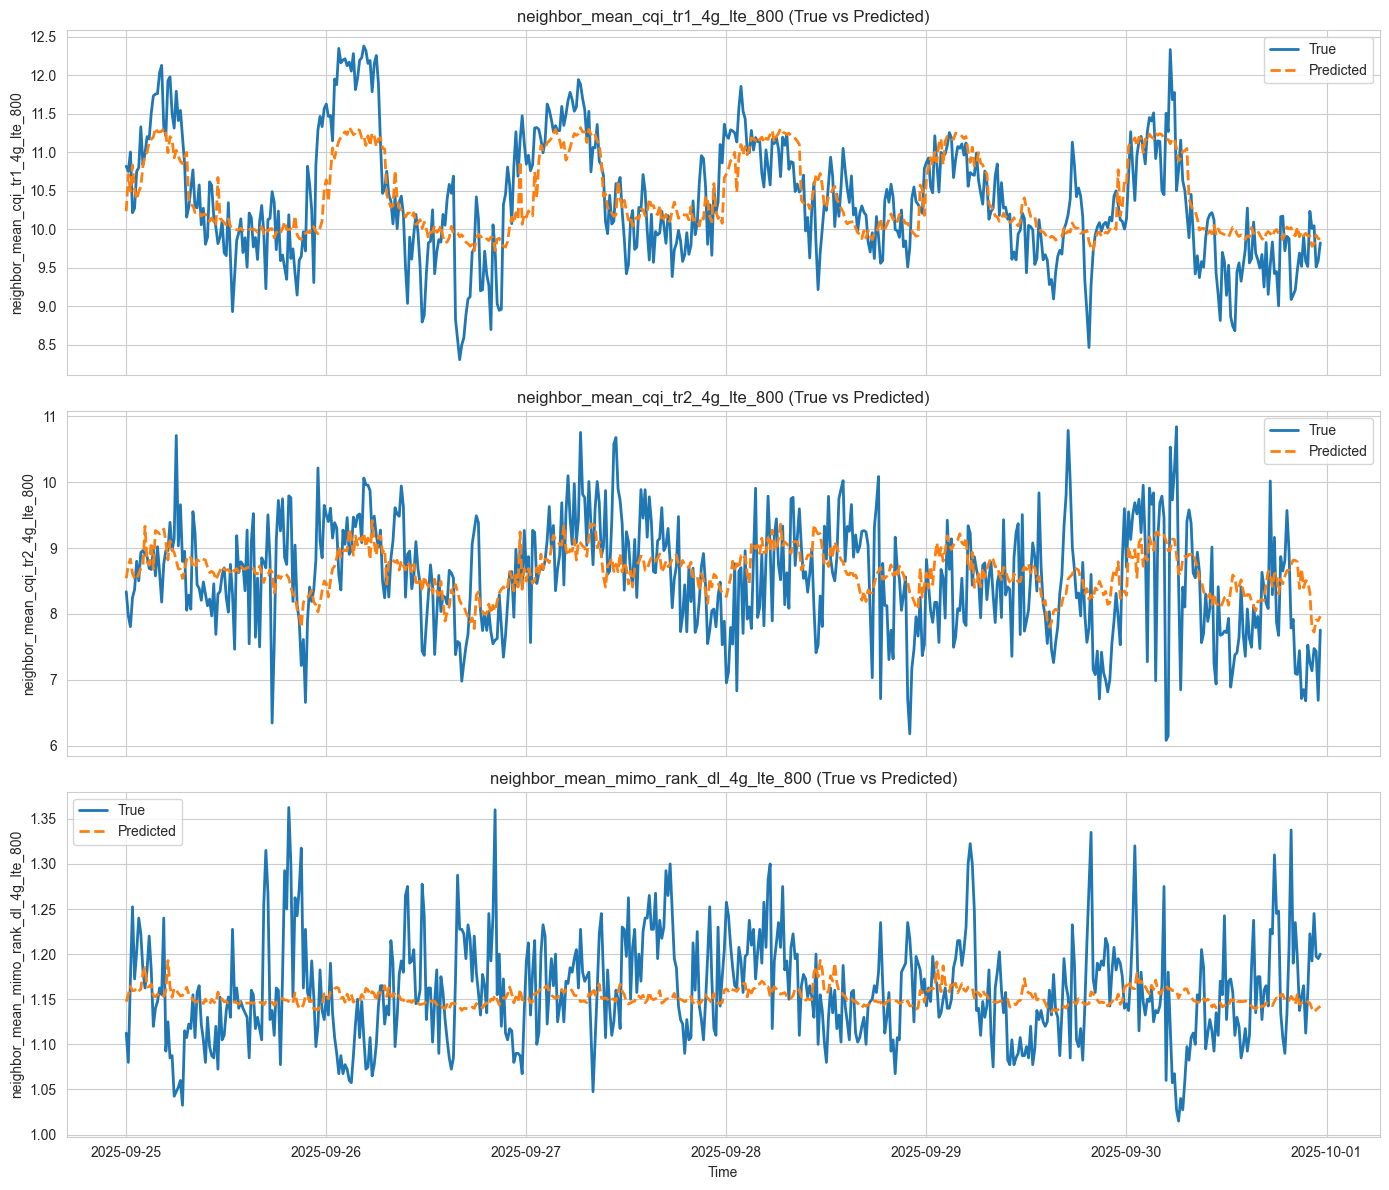

In [73]:
# ============================================================
# PLOT: TRUE vs PREDICTED (ALL METRICS)
# ============================================================

metrics = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# время
time_test = data.iloc[-len(y_test):][TIME_COL]

# создаём 3 графика (вертикально)
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 12), sharex=True)

for i, metric in enumerate(metrics):

    metric_idx = target_cols.index(metric)

    y_true = y_test.iloc[:, metric_idx].values
    y_pred_metric = y_pred[:, metric_idx]

    axes[i].plot(time_test, y_true, label="True", linewidth=2)
    axes[i].plot(time_test, y_pred_metric, linestyle="--", label="Predicted", linewidth=2)

    axes[i].set_ylabel(metric)
    axes[i].set_title(f"{metric} (True vs Predicted)")
    axes[i].grid(True)
    axes[i].legend()

# общий X
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

## 5: "4g_usage_%_lte_800", "data_volume_dl_4g_lte_800", "active_users_ul_4g_lte_800" "neighbor_usage_mean", "num_neighbors"

In [68]:
# ============================================================
# TIME SERIES MODEL: Predict next-step neighbor quality for ONE CELL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

CELL_ID = "TK1KAV3"
TIME_COL = "start_time"

feature_cols = [
    "4g_usage_%_lte_800",
    "data_volume_dl_4g_lte_800",
    "active_users_ul_4g_lte_800",
    "neighbor_usage_mean",
    "num_neighbors"
]

# реальные KPI (НЕ neighbor_mean!)
RAW_TARGETS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

# итоговые target'ы
target_cols = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

HISTORY_STEPS = 12  # 3 часа (12 × 15 мин)

# ============================================================
# 1. FILTER CELL DATA
# ============================================================

df_kpi[TIME_COL] = pd.to_datetime(df_kpi[TIME_COL])

df_cell = df_kpi[df_kpi["cell"] == CELL_ID].copy()
df_cell = df_cell.sort_values(TIME_COL)

print("Time points for cell:", len(df_cell))


# ============================================================
# 2. GET NEIGHBORS
# ============================================================

neighbor_dict = neighbor_table.set_index("cell")["neighbors"].to_dict()
neighbors = neighbor_dict.get(CELL_ID, [])

print("Number of neighbors:", len(neighbors))


# ============================================================
# 3. BUILD TARGET: NEIGHBOR MEAN QUALITY
# ============================================================

targets = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ][RAW_TARGETS]

    targets.append(vals.mean())

targets_df = pd.DataFrame(targets)
targets_df.columns = target_cols

df_cell = df_cell.reset_index(drop=True)
df_cell[target_cols] = targets_df

# ============================================================
# 3.5 BUILD FEATURE: NEIGHBOR USAGE MEAN
# ============================================================

neighbor_usage = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ]["4g_usage_%_lte_800"]

    neighbor_usage.append(vals.mean())

df_cell["neighbor_usage_mean"] = neighbor_usage

# количество соседей (константа)
df_cell["num_neighbors"] = len(neighbors)


# ============================================================
# 4. CREATE LAG FEATURES (HISTORY = 3 HOURS)
# ============================================================

data = df_cell.copy()

for col in feature_cols:
    for lag in range(1, HISTORY_STEPS + 1):
        data[f"{col}_lag_{lag}"] = data[col].shift(lag)

# target = следующий шаг
for col in target_cols:
    data[col] = data[col].shift(-1)

data = data.dropna()

print("Dataset after lagging:", len(data))


# ============================================================
# 5. TRAIN MODEL
# ============================================================

feature_lag_cols = [c for c in data.columns if "lag_" in c]

X = data[feature_lag_cols]
y = data[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 6. EVALUATION
# ============================================================

y_pred = model.predict(X_test)

for i, metric in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

    print(f"{metric}:")
    print(f"  R2  = {r2:.4f}")
    print(f"  MAE = {mae:.4f}")


# ============================================================
# 7. PREDICT NEXT STEP (15 MIN)
# ============================================================

last_row = data.iloc[-1]

X_last = last_row[feature_lag_cols].values.reshape(1, -1)

next_pred = model.predict(X_last)

print("\nNext 15-min prediction for", CELL_ID)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {next_pred[0][i]:.4f}")

Time points for cell: 2880
Number of neighbors: 5
Dataset after lagging: 2867
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.1621
  MAE = 0.4736
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = -0.1528
  MAE = 0.5160
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.0011
  MAE = 0.0704

Next 15-min prediction for TK1KAV3
neighbor_mean_cqi_tr1_4g_lte_800: 9.4221
neighbor_mean_cqi_tr2_4g_lte_800: 9.1954
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.3664


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


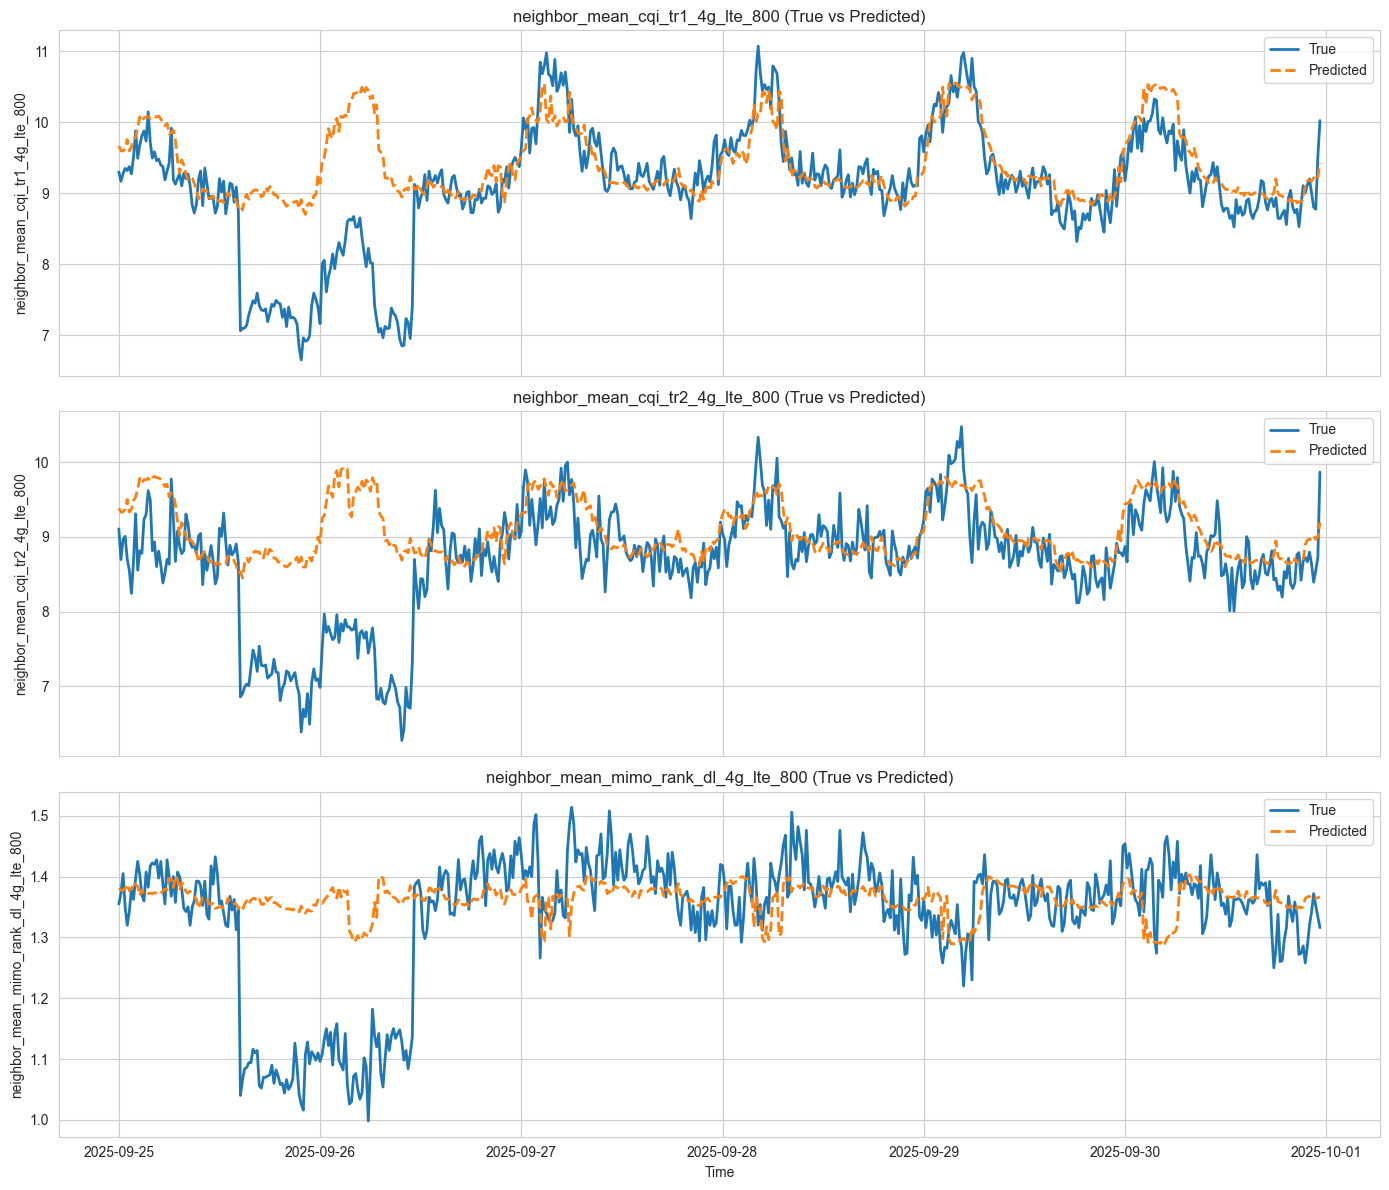

In [70]:
# ============================================================
# PLOT: TRUE vs PREDICTED (ALL METRICS)
# ============================================================

metrics = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# время
time_test = data.iloc[-len(y_test):][TIME_COL]

# создаём 3 графика (вертикально)
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 12), sharex=True)

for i, metric in enumerate(metrics):

    metric_idx = target_cols.index(metric)

    y_true = y_test.iloc[:, metric_idx].values
    y_pred_metric = y_pred[:, metric_idx]

    axes[i].plot(time_test, y_true, label="True", linewidth=2)
    axes[i].plot(time_test, y_pred_metric, linestyle="--", label="Predicted", linewidth=2)

    axes[i].set_ylabel(metric)
    axes[i].set_title(f"{metric} (True vs Predicted)")
    axes[i].grid(True)
    axes[i].legend()

# общий X
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# TIME SERIES MODEL: Predict next-step neighbor quality for ONE CELL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

CELL_ID = "TK3KRE2"
TIME_COL = "start_time"

feature_cols = [
    "4g_usage_%_lte_800",
    "data_volume_dl_4g_lte_800",
    "active_users_ul_4g_lte_800",
    "neighbor_usage_mean",
    "num_neighbors"
]

# реальные KPI (НЕ neighbor_mean!)
RAW_TARGETS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

# итоговые target'ы
target_cols = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

HISTORY_STEPS = 12  # 3 часа (12 × 15 мин)

# ============================================================
# 1. FILTER CELL DATA
# ============================================================

df_kpi[TIME_COL] = pd.to_datetime(df_kpi[TIME_COL])

df_cell = df_kpi[df_kpi["cell"] == CELL_ID].copy()
df_cell = df_cell.sort_values(TIME_COL)

print("Time points for cell:", len(df_cell))


# ============================================================
# 2. GET NEIGHBORS
# ============================================================

neighbor_dict = neighbor_table.set_index("cell")["neighbors"].to_dict()
neighbors = neighbor_dict.get(CELL_ID, [])

print("Number of neighbors:", len(neighbors))


# ============================================================
# 3. BUILD TARGET: NEIGHBOR MEAN QUALITY
# ============================================================

targets = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ][RAW_TARGETS]

    targets.append(vals.mean())

targets_df = pd.DataFrame(targets)
targets_df.columns = target_cols

df_cell = df_cell.reset_index(drop=True)
df_cell[target_cols] = targets_df

# ============================================================
# 3.5 BUILD FEATURE: NEIGHBOR USAGE MEAN
# ============================================================

neighbor_usage = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ]["4g_usage_%_lte_800"]

    neighbor_usage.append(vals.mean())

df_cell["neighbor_usage_mean"] = neighbor_usage

# количество соседей (константа)
df_cell["num_neighbors"] = len(neighbors)


# ============================================================
# 4. CREATE LAG FEATURES (HISTORY = 3 HOURS)
# ============================================================

data = df_cell.copy()

for col in feature_cols:
    for lag in range(1, HISTORY_STEPS + 1):
        data[f"{col}_lag_{lag}"] = data[col].shift(lag)

# target = следующий шаг
for col in target_cols:
    data[col] = data[col].shift(-1)

data = data.dropna()

print("Dataset after lagging:", len(data))


# ============================================================
# 5. TRAIN MODEL
# ============================================================

feature_lag_cols = [c for c in data.columns if "lag_" in c]

X = data[feature_lag_cols]
y = data[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 6. EVALUATION
# ============================================================

y_pred = model.predict(X_test)

for i, metric in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

    print(f"{metric}:")
    print(f"  R2  = {r2:.4f}")
    print(f"  MAE = {mae:.4f}")


# ============================================================
# 7. PREDICT NEXT STEP (15 MIN)
# ============================================================

last_row = data.iloc[-1]

X_last = last_row[feature_lag_cols].values.reshape(1, -1)

next_pred = model.predict(X_last)

print("\nNext 15-min prediction for", CELL_ID)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {next_pred[0][i]:.4f}")

Time points for cell: 2880
Number of neighbors: 4
Dataset after lagging: 2867
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.5720
  MAE = 0.4106
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = 0.1450
  MAE = 0.6130
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = -0.0462
  MAE = 0.0462

Next 15-min prediction for TK3KRE2
neighbor_mean_cqi_tr1_4g_lte_800: 9.8762
neighbor_mean_cqi_tr2_4g_lte_800: 7.9662
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.1423


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Model dokáže pomerne dobre predpovedať CQI TR1 (R² ≈ 0.57), čo znamená, že zachytáva hlavné trendy v dátach.
Pre CQI TR2 je výkon slabší (R² ≈ 0.15), takže model zachytáva len časť variability.
Pre MIMO rank je model neúspešný (záporné R²), čo naznačuje, že tento parameter závisí od iných faktorov, ktoré v modeli chýbajú.

### vizualizacia

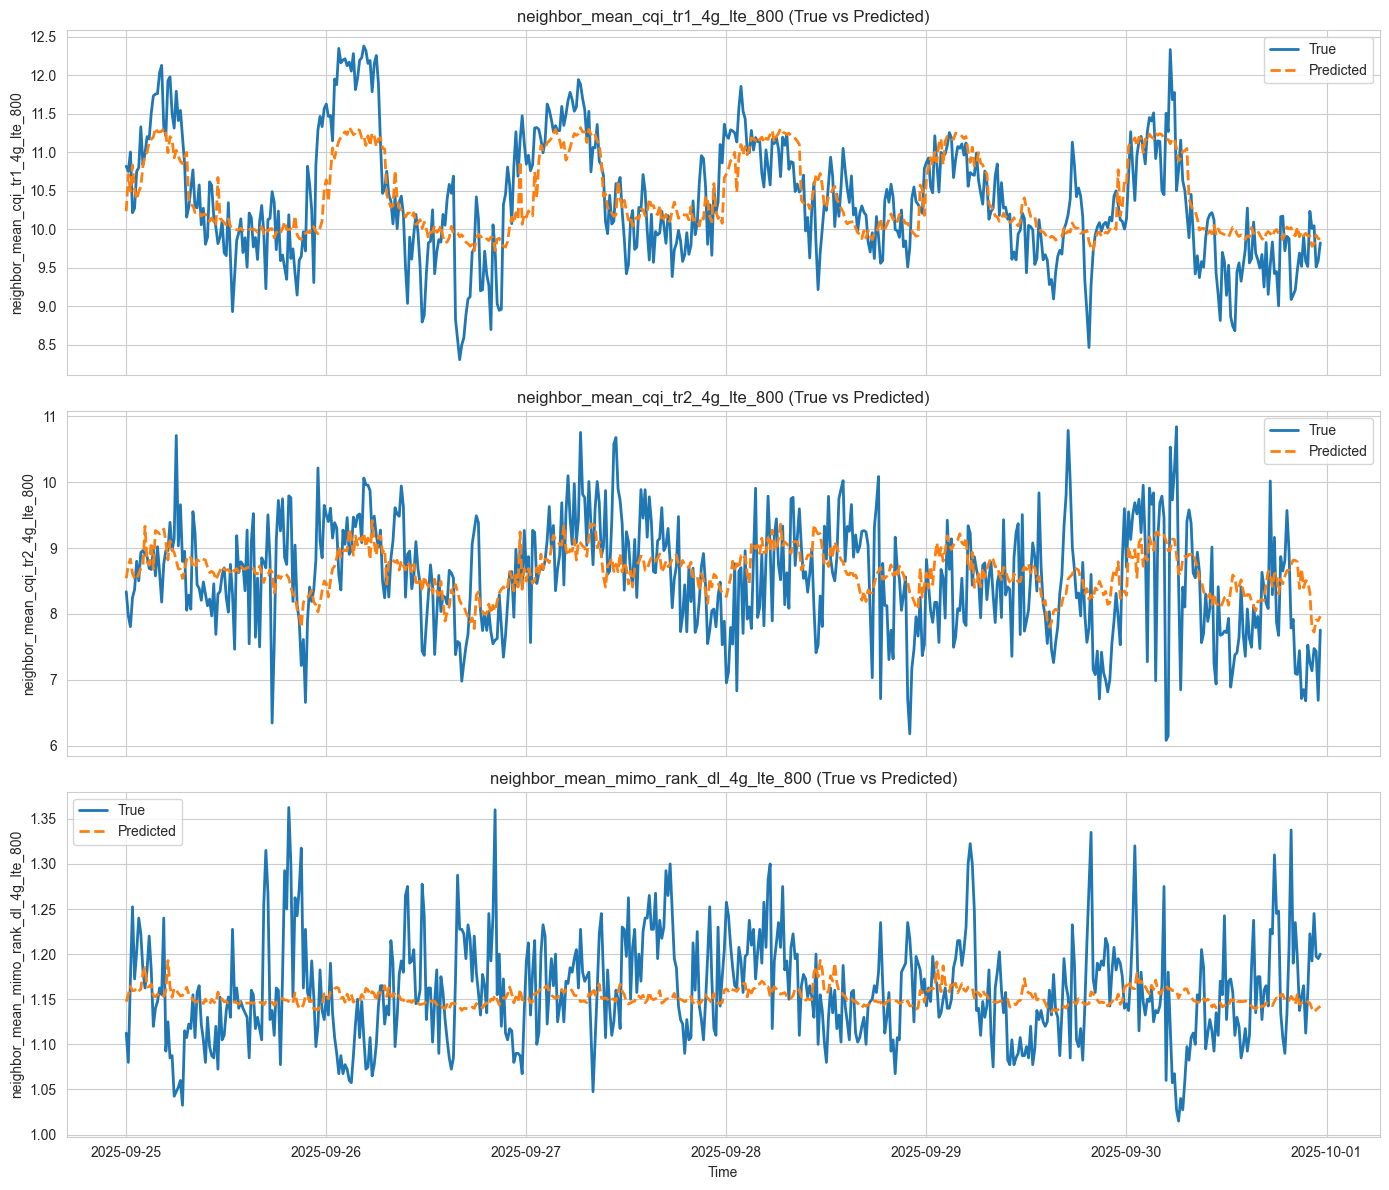

In [72]:
# ============================================================
# PLOT: TRUE vs PREDICTED (ALL METRICS)
# ============================================================

metrics = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# время
time_test = data.iloc[-len(y_test):][TIME_COL]

# создаём 3 графика (вертикально)
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 12), sharex=True)

for i, metric in enumerate(metrics):

    metric_idx = target_cols.index(metric)

    y_true = y_test.iloc[:, metric_idx].values
    y_pred_metric = y_pred[:, metric_idx]

    axes[i].plot(time_test, y_true, label="True", linewidth=2)
    axes[i].plot(time_test, y_pred_metric, linestyle="--", label="Predicted", linewidth=2)

    axes[i].set_ylabel(metric)
    axes[i].set_title(f"{metric} (True vs Predicted)")
    axes[i].grid(True)
    axes[i].legend()

# общий X
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# TIME SERIES MODEL: Predict next-step neighbor quality for ONE CELL
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

CELL_ID = "TK1THN3"
TIME_COL = "start_time"

feature_cols = [
    "4g_usage_%_lte_800",
    "data_volume_dl_4g_lte_800",
    "active_users_ul_4g_lte_800",
    "neighbor_usage_mean",
    "num_neighbors"
]

# реальные KPI (НЕ neighbor_mean!)
RAW_TARGETS = [
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]

# итоговые target'ы
target_cols = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

HISTORY_STEPS = 12  # 3 часа (12 × 15 мин)

# ============================================================
# 1. FILTER CELL DATA
# ============================================================

df_kpi[TIME_COL] = pd.to_datetime(df_kpi[TIME_COL])

df_cell = df_kpi[df_kpi["cell"] == CELL_ID].copy()
df_cell = df_cell.sort_values(TIME_COL)

print("Time points for cell:", len(df_cell))


# ============================================================
# 2. GET NEIGHBORS
# ============================================================

neighbor_dict = neighbor_table.set_index("cell")["neighbors"].to_dict()
neighbors = neighbor_dict.get(CELL_ID, [])

print("Number of neighbors:", len(neighbors))


# ============================================================
# 3. BUILD TARGET: NEIGHBOR MEAN QUALITY
# ============================================================

targets = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ][RAW_TARGETS]

    targets.append(vals.mean())

targets_df = pd.DataFrame(targets)
targets_df.columns = target_cols

df_cell = df_cell.reset_index(drop=True)
df_cell[target_cols] = targets_df

# ============================================================
# 3.5 BUILD FEATURE: NEIGHBOR USAGE MEAN
# ============================================================

neighbor_usage = []

for t in df_cell[TIME_COL]:

    vals = df_kpi[
        (df_kpi["cell"].isin(neighbors)) &
        (df_kpi[TIME_COL] == t)
    ]["4g_usage_%_lte_800"]

    neighbor_usage.append(vals.mean())

df_cell["neighbor_usage_mean"] = neighbor_usage

# количество соседей (константа)
df_cell["num_neighbors"] = len(neighbors)


# ============================================================
# 4. CREATE LAG FEATURES (HISTORY = 3 HOURS)
# ============================================================

data = df_cell.copy()

for col in feature_cols:
    for lag in range(1, HISTORY_STEPS + 1):
        data[f"{col}_lag_{lag}"] = data[col].shift(lag)

# target = следующий шаг
for col in target_cols:
    data[col] = data[col].shift(-1)

data = data.dropna()

print("Dataset after lagging:", len(data))


# ============================================================
# 5. TRAIN MODEL
# ============================================================

feature_lag_cols = [c for c in data.columns if "lag_" in c]

X = data[feature_lag_cols]
y = data[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)


# ============================================================
# 6. EVALUATION
# ============================================================

y_pred = model.predict(X_test)

for i, metric in enumerate(target_cols):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])

    print(f"{metric}:")
    print(f"  R2  = {r2:.4f}")
    print(f"  MAE = {mae:.4f}")


# ============================================================
# 7. PREDICT NEXT STEP (15 MIN)
# ============================================================

last_row = data.iloc[-1]

X_last = last_row[feature_lag_cols].values.reshape(1, -1)

next_pred = model.predict(X_last)

print("\nNext 15-min prediction for", CELL_ID)
for i, metric in enumerate(target_cols):
    print(f"{metric}: {next_pred[0][i]:.4f}")

Time points for cell: 2880
Number of neighbors: 3
Dataset after lagging: 2867
neighbor_mean_cqi_tr1_4g_lte_800:
  R2  = 0.6282
  MAE = 0.3736
neighbor_mean_cqi_tr2_4g_lte_800:
  R2  = 0.3151
  MAE = 0.3959
neighbor_mean_mimo_rank_dl_4g_lte_800:
  R2  = 0.0973
  MAE = 0.0419

Next 15-min prediction for TK1THN3
neighbor_mean_cqi_tr1_4g_lte_800: 8.2102
neighbor_mean_cqi_tr2_4g_lte_800: 7.3041
neighbor_mean_mimo_rank_dl_4g_lte_800: 1.1947


C:\Users\sirad\PycharmProjects\DP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


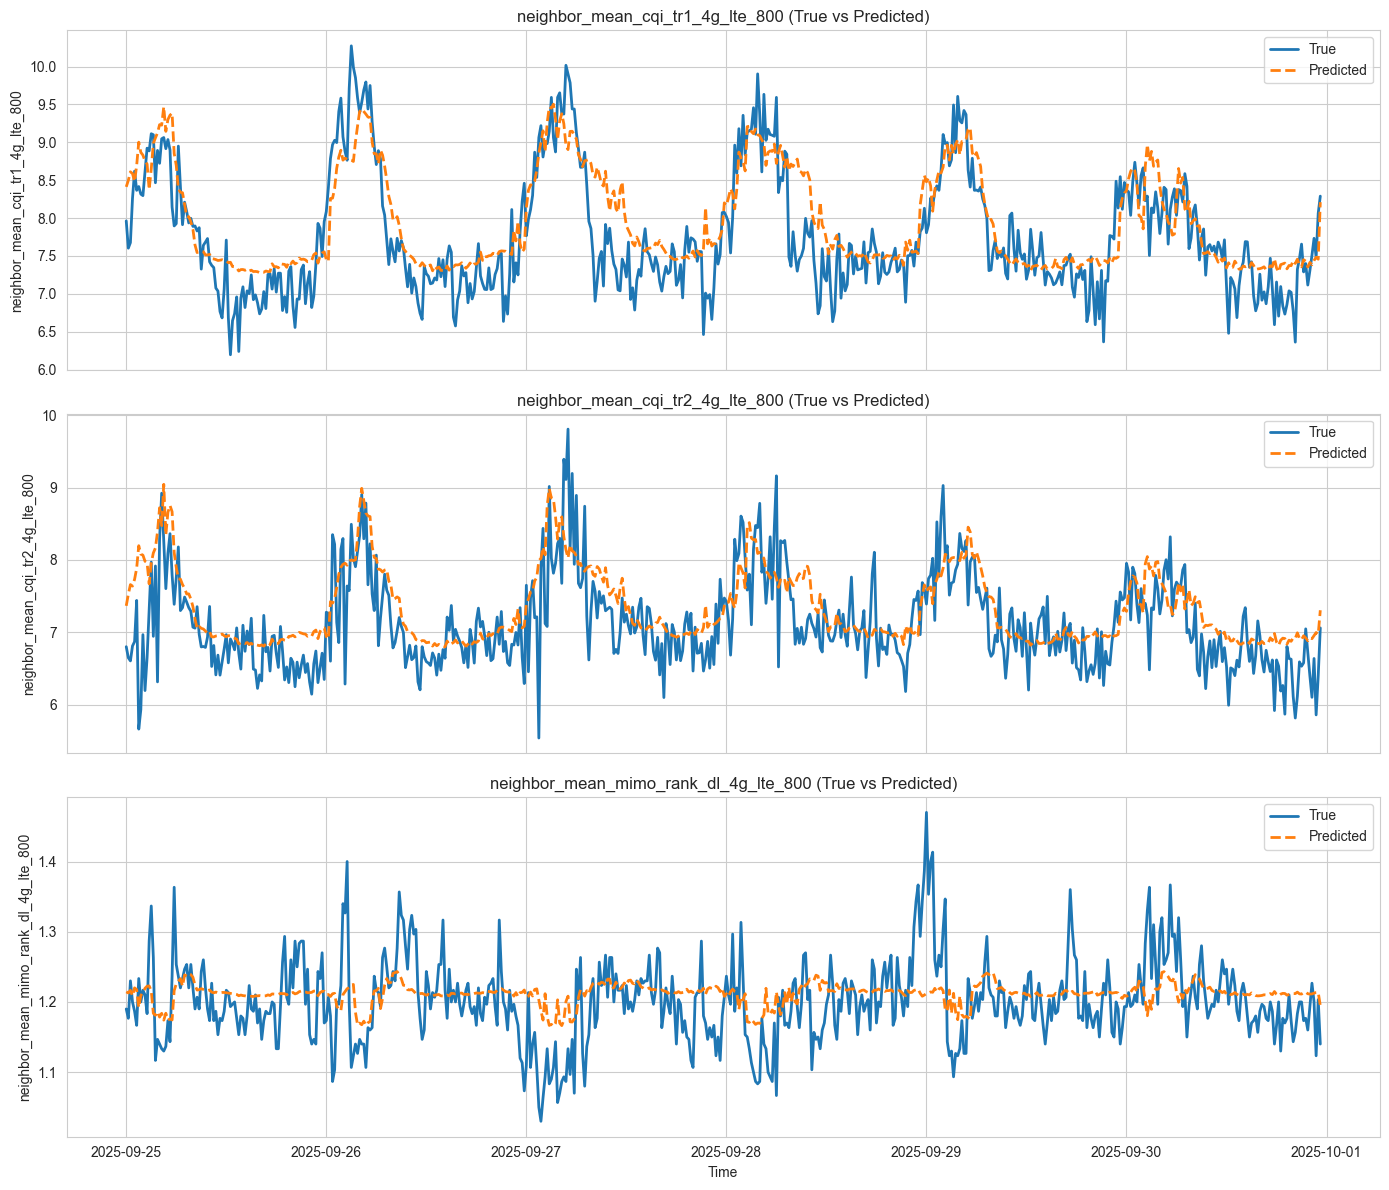

In [75]:
# ============================================================
# PLOT: TRUE vs PREDICTED (ALL METRICS)
# ============================================================

metrics = [
    "neighbor_mean_cqi_tr1_4g_lte_800",
    "neighbor_mean_cqi_tr2_4g_lte_800",
    "neighbor_mean_mimo_rank_dl_4g_lte_800"
]

# время
time_test = data.iloc[-len(y_test):][TIME_COL]

# создаём 3 графика (вертикально)
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 12), sharex=True)

for i, metric in enumerate(metrics):

    metric_idx = target_cols.index(metric)

    y_true = y_test.iloc[:, metric_idx].values
    y_pred_metric = y_pred[:, metric_idx]

    axes[i].plot(time_test, y_true, label="True", linewidth=2)
    axes[i].plot(time_test, y_pred_metric, linestyle="--", label="Predicted", linewidth=2)

    axes[i].set_ylabel(metric)
    axes[i].set_title(f"{metric} (True vs Predicted)")
    axes[i].grid(True)
    axes[i].legend()

# общий X
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()